In [1]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak

## Considering Four Different Spaces in stage1_training data

In [2]:
# file location Bs signal
filepath = "/r01/lhcb/ejnw2/fcc/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/stage1_training/p8_ee_Zud_ecm91/chunk_0.root"

# Create instance of uproot, we have opened the file
uproot_file = uproot.open( filepath)

# Look at trees in file
print( "Trees : " , uproot_file.keys() )

# We want output events
tree = uproot_file['events']

'''
print( "Variables:" )

for branch in tree.keys():
    print( branch )
'''

# Get data out

# define variables we want out
branches_PV = [
    "Rec_PV_ntracks",
    "Rec_PV_x",
    "Rec_PV_y",
    "Rec_PV_z",
    ]

branches_rec_vtx = [
    "Rec_vtx_ntracks",
    "Rec_vtx_chi2",
    "Rec_vtx_isPV",
    "Rec_vtx_m",
    "Rec_vtx_x",
    "Rec_vtx_y",
    "Rec_vtx_z",
    "Rec_vtx_xerr",
    "Rec_vtx_yerr",
    "Rec_vtx_zerr",
    ]
branches_rec = [
    "Rec_type",
    "Rec_indvtx",
    "Rec_customid",
    "Rec_e",
    "Rec_m",
    "Rec_q",
    "Rec_p",
    "Rec_pt",
    "Rec_px",
    "Rec_py",
    "Rec_pz",
    "Rec_eta",
    "Rec_phi",
    "Rec_thrustCosTheta",
    "Rec_in_hemisEmin",
    "Rec_in_hemisEmax",
    ]

branches_rec_true = [
   "Rec_true_PDG",
    "Rec_true_e",
    "Rec_true_m",
    "Rec_true_q",
    "Rec_true_p",
    "Rec_true_pt",
    "Rec_true_px",
    "Rec_true_py",
    "Rec_true_pz",
    "Rec_true_eta",
    "Rec_true_phi",
    "Rec_true_orivtx_x",
    "Rec_true_orivtx_y",
    "Rec_true_orivtx_z",
    "Rec_true_M1",
    "Rec_true_M2",
    "Rec_true_M1ofM1",
    "Rec_true_M2ofM1",
    "Rec_true_M1ofM2",
    "Rec_true_M2ofM2",
    ]

branches_evt =[
    "EVT_Thrust_mag",
    "EVT_Thrust_x",
    "EVT_Thrust_y",
    "EVT_Thrust_z",
    "EVT_Thrust_xerr",
    "EVT_Thrust_yerr",
    "EVT_Thrust_zerr",
    "EVT_Thrust_deltaE",
    "EVT_hemisEmin_Emiss",
    "EVT_hemisEmax_Emiss",
    "EVT_hemisEmin_e",
    "EVT_hemisEmin_eCharged",
    "EVT_hemisEmin_eNeutral",
    "EVT_hemisEmin_n",
    "EVT_hemisEmin_nCharged",
    "EVT_hemisEmin_nNeutral",
    "EVT_hemisEmin_nDV",
    "EVT_hemisEmax_e",
    "EVT_hemisEmax_eCharged",
    "EVT_hemisEmax_eNeutral",
    "EVT_hemisEmax_n",
    "EVT_hemisEmax_nCharged",
    "EVT_hemisEmax_nNeutral",
    "EVT_hemisEmax_nDV",
    "Rec_track_n",
    "Rec_n",
    "Rec_vtx_n",
]

branches_track = ["Rec_vtx_indRP",]



akar_EVT = tree.arrays(
    expressions = branches_evt+branches_PV , 
    library = 'ak' ,
)
akar_RP = tree.arrays(
    expressions = branches_rec , 
    library = 'ak' ,
)
akar_vtx = tree.arrays(
    expressions = branches_rec_vtx , 
    library = 'ak' ,
)

akar_track = tree.arrays(
    expressions = branches_track, 
    library = 'ak' ,
)

# close file
#uproot_file.close()


Trees :  ['events;1', 'eventsProcessed;1', 'eventsSelected;1']


In [3]:
# List of variables in the first script
list1=[]
for branch in tree.keys():
    list1.append(branch)

list2 = branches_evt+branches_rec+branches_rec_vtx+branches_track+branches_PV+branches_rec_true
 
# Check if all variables in list1 are in list2
missing_vars = [var for var in list1 if var not in list2]

if not missing_vars:
    print("All variables from list1 are present in list2.")
else:
    print("The following variables from list1 are missing in list2:")
    for var in missing_vars:
        print(var)

missing_vars = [var for var in list2 if var not in list1]

if not missing_vars:
    print("All variables from list2 are present in list1.")
else:
    print("The following variables from list2 are missing in list1:")
    for var in missing_vars:
        print(var)


All variables from list1 are present in list2.
All variables from list2 are present in list1.


In [4]:
df_vtx = ak.to_dataframe(akar_vtx,how=None)

df_vtx


[                Rec_vtx_ntracks  Rec_vtx_chi2  Rec_vtx_isPV  Rec_vtx_m  \
 entry subentry                                                           
 0     0                      15      0.782826             1  28.669641   
       1                       2      0.018884             0   1.115797   
       2                       2      0.488044             0   0.497695   
 1     0                      28      0.904264             1  57.026760   
 2     0                       7      1.041161             1  29.950649   
 ...                         ...           ...           ...        ...   
 69782 0                      26      1.081723             1  39.355366   
 69783 0                      22      0.985017             1  62.568371   
       1                       2      0.857216             0   0.500512   
 69784 0                      23      1.557819             1  33.295349   
 69785 0                      22      0.958163             1  68.045486   
 
                  Rec_v

In [5]:
len(df_vtx[0]['Rec_vtx_yerr'][0])

3

In [6]:
list(df_vtx[0].columns)



['Rec_vtx_ntracks',
 'Rec_vtx_chi2',
 'Rec_vtx_isPV',
 'Rec_vtx_m',
 'Rec_vtx_x',
 'Rec_vtx_y',
 'Rec_vtx_z',
 'Rec_vtx_xerr',
 'Rec_vtx_yerr',
 'Rec_vtx_zerr']

In [7]:
df_EVT = ak.to_dataframe(akar_EVT, how=None)

df_EVT

[       EVT_Thrust_mag  EVT_Thrust_x  EVT_Thrust_y  EVT_Thrust_z  \
 entry                                                             
 0            0.775558      1.761447     -0.503175     -0.194272   
 1            0.809841      1.566142      0.961518      0.255219   
 2            0.959726     -1.393674      1.339273      0.190867   
 3            0.961582     -0.316154     -0.592191     -1.697890   
 4            0.784304      0.282774      1.683236      1.250263   
 ...               ...           ...           ...           ...   
 69781        0.952897      0.130504     -0.136705     -1.495880   
 69782        0.704618      1.017971     -0.533741     -2.463194   
 69783        0.658537     -0.207457     -0.575404      1.593246   
 69784        0.863490      0.477829      0.641609      1.524437   
 69785        0.501723     -0.926437     -1.007781     -1.274301   
 
        EVT_Thrust_xerr  EVT_Thrust_yerr  EVT_Thrust_zerr  EVT_Thrust_deltaE  \
 entry                            

In [8]:
list(df_EVT[0].columns)


['EVT_Thrust_mag',
 'EVT_Thrust_x',
 'EVT_Thrust_y',
 'EVT_Thrust_z',
 'EVT_Thrust_xerr',
 'EVT_Thrust_yerr',
 'EVT_Thrust_zerr',
 'EVT_Thrust_deltaE',
 'EVT_hemisEmin_Emiss',
 'EVT_hemisEmax_Emiss',
 'EVT_hemisEmin_e',
 'EVT_hemisEmin_eCharged',
 'EVT_hemisEmin_eNeutral',
 'EVT_hemisEmin_n',
 'EVT_hemisEmin_nCharged',
 'EVT_hemisEmin_nNeutral',
 'EVT_hemisEmin_nDV',
 'EVT_hemisEmax_e',
 'EVT_hemisEmax_eCharged',
 'EVT_hemisEmax_eNeutral',
 'EVT_hemisEmax_n',
 'EVT_hemisEmax_nCharged',
 'EVT_hemisEmax_nNeutral',
 'EVT_hemisEmax_nDV',
 'Rec_track_n',
 'Rec_n',
 'Rec_vtx_n',
 'Rec_PV_ntracks',
 'Rec_PV_x',
 'Rec_PV_y',
 'Rec_PV_z']

In [9]:

df_RP = ak.to_dataframe(akar_RP, how=None)

df_RP



[                Rec_type  Rec_indvtx  Rec_customid      Rec_e     Rec_m  \
 entry subentry                                                            
 0     0              211           2            44   0.537173  0.139570   
       1              211           2            44   0.655819  0.139570   
       2              211           0            44   0.509229  0.139570   
       3              211           0            44   1.258366  0.139570   
       4              321           0            44   2.001005  0.493677   
 ...                  ...         ...           ...        ...       ...   
 69785 32              22        -999            10   0.702819  0.000281   
       33              22        -999            10   0.271676 -0.000082   
       34              22        -999            10   0.155592 -0.000015   
       35              22        -999            10   0.195785 -0.000082   
       36             130        -999            34  10.807200  0.497602   
 
          

In [10]:
len(df_RP[0]['Rec_type'][0])

44

In [11]:
list(df_RP[0].columns)


['Rec_type',
 'Rec_indvtx',
 'Rec_customid',
 'Rec_e',
 'Rec_m',
 'Rec_q',
 'Rec_p',
 'Rec_pt',
 'Rec_px',
 'Rec_py',
 'Rec_pz',
 'Rec_eta',
 'Rec_phi',
 'Rec_thrustCosTheta',
 'Rec_in_hemisEmin',
 'Rec_in_hemisEmax']

In [12]:
df_track = ak.to_dataframe(akar_track, how=None)

df_track



[                            Rec_vtx_indRP
 entry subentry subsubentry               
 0     0        0                        2
                1                        3
                2                        4
                3                        5
                4                        6
 ...                                   ...
 69785 0        17                      17
                18                      18
                19                      19
                20                      20
                21                      21
 
 [1442056 rows x 1 columns]]

In [13]:
len(df_track[0]['Rec_vtx_indRP'][0])

19

In [14]:
df_EVT[0]['Rec_track_n'][0]

19.0

In [15]:
list(df_track[0].columns)

['Rec_vtx_indRP']

### Investigating number of tracks missed in vertexing

In [16]:
track_indRP_size=[]
for i in range(len(df_EVT[0]['Rec_track_n'])):
    track_indRP_size.append(len(df_track[0]['Rec_vtx_indRP'][i]))


In [17]:
df_EVT[0]['Rec_track_n']

entry
0        19.0
1        28.0
2        10.0
3        15.0
4        27.0
         ... 
69781     9.0
69782    27.0
69783    24.0
69784    24.0
69785    22.0
Name: Rec_track_n, Length: 69786, dtype: float32

In [18]:
df_Rec_track_n = df_EVT[0].loc[:,['Rec_track_n']]
df_Rec_track_n

,Rec_track_n
entry,
0,19.0
1,28.0
2,10.0
3,15.0
4,27.0
...,...
69781,9.0
69782,27.0
69783,24.0


In [19]:
# Initialize list to hold differences
differences = []

# Compare DataFrame columns with list elements
for col in df_Rec_track_n.columns:
    for i, val in enumerate(df_Rec_track_n[col]):
        if i < len(track_indRP_size) and val != track_indRP_size[i]:
            differences.append({'Index': i, 'Column': col, 'Rec_track_n': val, 'Rec_vtx_indRP_size': track_indRP_size[i]})

# Create a DataFrame of differences
diff_df = pd.DataFrame(differences)

# Display the DataFrame of differences
diff_df


,Index,Column,Rec_track_n,Rec_vtx_indRP_size
0,2,Rec_track_n,10.0,9
1,8,Rec_track_n,21.0,20
2,9,Rec_track_n,9.0,8
3,10,Rec_track_n,20.0,18
4,11,Rec_track_n,20.0,19
...,...,...,...,...
24589,69773,Rec_track_n,31.0,29
24590,69774,Rec_track_n,39.0,38
24591,69775,Rec_track_n,20.0,17
24592,69782,Rec_track_n,27.0,26


In [20]:
len(diff_df.index)/len(df_Rec_track_n.index)

0.35242025621184764

In [21]:
sum_Rec_vtx_ntrack=[]
for j in range(len(df_EVT[0]['Rec_n'])):   
    sum_Rec_vtx_ntrack.append(np.sum(df_vtx[0]['Rec_vtx_ntracks'][j]))

In [22]:
# Initialize list to hold differences
differences = []

# Compare DataFrame columns with list elements
for col in df_Rec_track_n.columns:
    for i, val in enumerate(df_Rec_track_n[col]):
        if i < len(sum_Rec_vtx_ntrack) and val != sum_Rec_vtx_ntrack[i]:
            differences.append({'Index': i, 'Column': col, 'Rec_track_n': val, 'sum_Rec_vtx_ntrack': sum_Rec_vtx_ntrack[i]})

# Create a DataFrame of differences
diff_df = pd.DataFrame(differences)

# Display the DataFrame of differences
diff_df


,Index,Column,Rec_track_n,sum_Rec_vtx_ntrack
0,2,Rec_track_n,10.0,9
1,8,Rec_track_n,21.0,20
2,9,Rec_track_n,9.0,8
3,10,Rec_track_n,20.0,18
4,11,Rec_track_n,20.0,19
...,...,...,...,...
24589,69773,Rec_track_n,31.0,29
24590,69774,Rec_track_n,39.0,38
24591,69775,Rec_track_n,20.0,17
24592,69782,Rec_track_n,27.0,26


In [23]:

# Check if the two lists are identical
are_identical_1 = sum_Rec_vtx_ntrack == track_indRP_size


# Output the results
print(f"sum_Rec_vtx_ntrack and track_indRP_size are identical: {are_identical_1}")



sum_Rec_vtx_ntrack and track_indRP_size are identical: True


In [24]:
len(diff_df.index)/len(df_Rec_track_n.index)

0.35242025621184764

### Investigating number of tracks in PV fit

In [25]:
df_PV_ntracks=df_EVT[0].loc[:,['Rec_PV_ntracks']]

In [26]:
df_vtx_ntracks_PV=df_vtx[0][df_vtx[0]['Rec_vtx_isPV']==True].loc[:,['Rec_vtx_ntracks']]

In [27]:
# Initialize list to hold differences
differences = []

# Compare DataFrame columns with list elements
for col in df_PV_ntracks.columns:
    for i, val in enumerate(df_PV_ntracks[col]):
        if i < len(df_vtx_ntracks_PV.index) and val != df_vtx_ntracks_PV['Rec_vtx_ntracks'][i].item():
            differences.append({'Index': i, 'Column': col, 'PV_ntracks': val, 'vtx_ntracks_PV': df_vtx_ntracks_PV['Rec_vtx_ntracks'][i].item()})

# Create a DataFrame of differences
diff_df = pd.DataFrame(differences)

# Display the DataFrame of differences
diff_df


,Index,Column,PV_ntracks,vtx_ntracks_PV
0,1,Rec_PV_ntracks,27.0,28
1,3,Rec_PV_ntracks,14.0,13
2,4,Rec_PV_ntracks,26.0,27
3,5,Rec_PV_ntracks,10.0,11
4,6,Rec_PV_ntracks,21.0,22
...,...,...,...,...
28734,69777,Rec_PV_ntracks,23.0,24
28735,69779,Rec_PV_ntracks,9.0,10
28736,69780,Rec_PV_ntracks,16.0,17
28737,69781,Rec_PV_ntracks,8.0,9


In [28]:
len(diff_df.index)/len(df_Rec_track_n.index)

0.41181612357779496

## Considering Spaces in Ritwik stage2 data

In [29]:
# file location Bs signal
filepath = "/r02/lhcb/rrm42/fcc/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/stage2/p8_ee_Zud_ecm91/chunk_0.root"
# Create instance of uproot, we have opened the file
uproot_file = uproot.open( filepath)

# Look at trees in file
print( "Trees : " , uproot_file.keys() )

# We want output events
tree = uproot_file['events']

'''
print( "Variables:" )

for branch in tree.keys():
    print( branch )
'''

# Get data out

# define variables we want out

branches_rec_vtx = [
    "Rec_vtx_ntracks",
    "Rec_vtx_chi2",
    "Rec_vtx_isPV",
    "Rec_vtx_m",
    "Rec_vtx_x",
    "Rec_vtx_y",
    "Rec_vtx_z",
    "Rec_vtx_xerr",
    "Rec_vtx_yerr",
    "Rec_vtx_zerr",
    "Rec_vtx_d2PV_signed",
    "Rec_vtx_d2PV_x",
    "Rec_vtx_d2PV_y",
    "Rec_vtx_d2PV_z",
    "Rec_vtx_d2PV_err",
    "Rec_vtx_d2PV_xerr",
    "Rec_vtx_d2PV_yerr",
    "Rec_vtx_d2PV_zerr",
    "Rec_vtx_normd2PV_signed",
    "Rec_vtx_normd2PV_x",
    "Rec_vtx_normd2PV_y",
    "Rec_vtx_normd2PV_z",
    "Rec_vtx_thrustCosTheta",
    "Rec_vtx_in_hemisEmin"
]


branches_rec = [
    "Rec_true_PDG",
    "Rec_true_e",
    "Rec_true_m",
    "Rec_true_q",
    "Rec_true_p",
    "Rec_true_pt",
    "Rec_true_px",
    "Rec_true_py",
    "Rec_true_pz",
    "Rec_true_eta",
    "Rec_true_phi",
    "Rec_true_orivtx_x",
    "Rec_true_orivtx_y",
    "Rec_true_orivtx_z",
    "Rec_true_M1",
    "Rec_true_M2",
    "Rec_true_M1ofM1",
    "Rec_true_M2ofM1",
    "Rec_true_M1ofM2",
    "Rec_true_M2ofM2",
    "Rec_type",
    "Rec_indvtx",
    "Rec_customid",
    "Rec_e",
    "Rec_m",
    "Rec_q",
    "Rec_p",
    "Rec_pt",
    "Rec_px",
    "Rec_py",
    "Rec_pz",
    "Rec_eta",
    "Rec_phi",
    "Rec_thrustCosTheta",
    "Rec_in_hemisEmin",
    "Rec_track_d0",
    "Rec_track_z0",
    "Rec_track_normd0",
    "Rec_track_normz0"
]

branches_evt = [
    "EVT_MVA1",
    "EVT_MVA2",
    "EVT_MVAComb",
    "EVT_Thrust_mag",
    "EVT_Thrust_x",
    "EVT_Thrust_y",
    "EVT_Thrust_z",
    "EVT_Thrust_xerr",
    "EVT_Thrust_yerr",
    "EVT_Thrust_zerr",
    "EVT_Thrust_deltaE",
    "EVT_hemisEmin_Emiss",
    "EVT_hemisEmax_Emiss",
    "EVT_hemisEmin_e",
    "EVT_hemisEmin_eCharged",
    "EVT_hemisEmin_eNeutral",
    "EVT_hemisEmin_n",
    "EVT_hemisEmin_nCharged",
    "EVT_hemisEmin_nNeutral",
    "EVT_hemisEmin_nDV",
    "EVT_hemisEmax_e",
    "EVT_hemisEmax_eCharged",
    "EVT_hemisEmax_eNeutral",
    "EVT_hemisEmax_n",
    "EVT_hemisEmax_nCharged",
    "EVT_hemisEmax_nNeutral",
    "EVT_hemisEmax_nDV",
    "EVT_hemisEmin_nKaon",
    "EVT_hemisEmin_nPion",
    "EVT_hemisEmin_maxeKaon",
    "EVT_hemisEmin_maxePion",
    "EVT_hemisEmin_maxeKaon_fromtruePV",
    "EVT_hemisEmin_maxePion_fromtruePV",
    "EVT_hemisEmin_maxeKaon_ind",
    "EVT_hemisEmin_maxePion_ind",
    "EVT_hemisEmax_nLept",
    "EVT_hemisEmax_nKaon",
    "EVT_hemisEmax_nPion",
    "EVT_hemisEmax_maxeLept",
    "EVT_hemisEmax_maxeKaon",
    "EVT_hemisEmax_maxePion",
    "EVT_hemisEmax_maxeLept_fromtruePV",
    "EVT_hemisEmax_maxeKaon_fromtruePV",
    "EVT_hemisEmax_maxePion_fromtruePV",
    "EVT_hemisEmax_maxeLept_ind",
    "EVT_hemisEmax_maxeKaon_ind",
    "EVT_hemisEmax_maxePion_ind",
    "EVT_hemisEmin_containsTau23Pi",
    "Rec_PV_ntracks",
    "Rec_PV_x",
    "Rec_PV_y",
    "Rec_PV_z",
    "Rec_thrustCosTheta_min_hemisEmin",
    "Rec_thrustCosTheta_max_hemisEmin",
    "Rec_thrustCosTheta_ave_hemisEmin",
    "Rec_thrustCosTheta_min_hemisEmax",
    "Rec_thrustCosTheta_max_hemisEmax",
    "Rec_thrustCosTheta_ave_hemisEmax",
    "Rec_thrustCosTheta_min_hemisEmin_noBrem",
    "Rec_thrustCosTheta_max_hemisEmin_noBrem",
    "Rec_thrustCosTheta_ave_hemisEmin_noBrem",
    "Rec_thrustCosTheta_min_hemisEmax_noBrem",
    "Rec_thrustCosTheta_max_hemisEmax_noBrem",
    "Rec_thrustCosTheta_ave_hemisEmax_noBrem",
    "Rec_track_d0_min_hemisEmin",
    "Rec_track_d0_max_hemisEmin",
    "Rec_track_d0_ave_hemisEmin",
    "Rec_track_z0_min_hemisEmin",
    "Rec_track_z0_max_hemisEmin",
    "Rec_track_z0_ave_hemisEmin",
    "Rec_track_d0_min_hemisEmax",
    "Rec_track_d0_max_hemisEmax",
    "Rec_track_d0_ave_hemisEmax",
    "Rec_track_z0_min_hemisEmax",
    "Rec_track_z0_max_hemisEmax",
    "Rec_track_z0_ave_hemisEmax",
    "Rec_vtx_d2PV_min_hemisEmin",
    "Rec_vtx_d2PV_max_hemisEmin",
    "Rec_vtx_d2PV_ave_hemisEmin",
    "Rec_vtx_d2PV_min_hemisEmax",
    "Rec_vtx_d2PV_max_hemisEmax",
    "Rec_vtx_d2PV_ave_hemisEmax",
    "Rec_vtx_ntracks_min_hemisEmin",
    "Rec_vtx_ntracks_max_hemisEmin",
    "Rec_vtx_ntracks_ave_hemisEmin",
    "Rec_vtx_ntracks_min_hemisEmax",
    "Rec_vtx_ntracks_max_hemisEmax",
    "Rec_vtx_ntracks_ave_hemisEmax",
    "Rec_vtx_thrustCosTheta_min_hemisEmin",
    "Rec_vtx_thrustCosTheta_max_hemisEmin",
    "Rec_vtx_thrustCosTheta_ave_hemisEmin",
    "Rec_vtx_thrustCosTheta_min_hemisEmax",
    "Rec_vtx_thrustCosTheta_max_hemisEmax",
    "Rec_vtx_thrustCosTheta_ave_hemisEmax",
    "Rec_vtx_n",
    "Rec_track_n",
    "Rec_n"
]



branches_track = ["Rec_vtx_indRP",
]

branches_MC_evt_space = [
    "MCem_e",
    "MCem_m",
    "MCem_q",
    "MCem_p",
    "MCem_pt",
    "MCem_px",
    "MCem_py",
    "MCem_pz",
    "MCem_eta",
    "MCem_phi",
    "MCem_orivtx_x",
    "MCem_orivtx_y",
    "MCem_orivtx_z",
    "MCep_e",
    "MCep_m",
    "MCep_q",
    "MCep_p",
    "MCep_pt",
    "MCep_px",
    "MCep_py",
    "MCep_pz",
    "MCep_eta",
    "MCep_phi",
    "MCep_orivtx_x",
    "MCep_orivtx_y",
    "MCep_orivtx_z",
    "MCZ_e",
    "MCZ_m",
    "MCZ_q",
    "MCZ_p",
    "MCZ_pt",
    "MCZ_px",
    "MCZ_py",
    "MCZ_pz",
    "MCZ_eta",
    "MCZ_phi",
    "MCZ_orivtx_x",
    "MCZ_orivtx_y",
    "MCZ_orivtx_z",
    "MCq1_PDG",
    "MCq1_e",
    "MCq1_m",
    "MCq1_q",
    "MCq1_p",
    "MCq1_pt",
    "MCq1_px",
    "MCq1_py",
    "MCq1_pz",
    "MCq1_eta",
    "MCq1_phi",
    "MCq1_orivtx_x",
    "MCq1_orivtx_y",
    "MCq1_orivtx_z",
    "MCq2_PDG",
    "MCq2_e",
    "MCq2_m",
    "MCq2_q",
    "MCq2_p",
    "MCq2_pt",
    "MCq2_px",
    "MCq2_py",
    "MCq2_pz",
    "MCq2_eta",
    "MCq2_phi",
    "MCq2_orivtx_x",
    "MCq2_orivtx_y",
    "MCq2_orivtx_z"
]



akar_EVT = tree.arrays(
    expressions = branches_evt, 
    library = 'ak' ,
)
akar_RP = tree.arrays(
    expressions = branches_rec , 
    library = 'ak' ,
)
akar_vtx = tree.arrays(
    expressions = branches_rec_vtx , 
    library = 'ak' ,
)

akar_track = tree.arrays(
    expressions = branches_track, 
    library = 'ak' ,
)

akar_MC_evtsp = tree.arrays(
    expressions = branches_MC_evt_space,
    library = 'ak',
)

# close file
#uproot_file.close()


Trees :  ['events;1', 'eventsProcessed;1', 'eventsSelected;1']


In [30]:
#check not missed any vars

# List of variables in the first script
list1=[]
for branch in tree.keys():
    list1.append(branch)

list2 = branches_evt+branches_rec+branches_rec_vtx+branches_track+branches_MC_evt_space
 
# Check if all variables in list1 are in list2
missing_vars = [var for var in list1 if var not in list2]

if not missing_vars:
    print("All variables from list1 are present in list2.")
else:
    print("The following variables from list1 are missing in list2:")
    for var in missing_vars:
        print(var)

missing_vars = [var for var in list2 if var not in list1]

if not missing_vars:
    print("All variables from list2 are present in list1.")
else:
    print("The following variables from list2 are missing in list1:")
    for var in missing_vars:
        print(var)



All variables from list1 are present in list2.
All variables from list2 are present in list1.


In [31]:
df_vtx = ak.to_dataframe(akar_vtx,how=None)

df_vtx



[                Rec_vtx_ntracks  Rec_vtx_chi2  Rec_vtx_isPV  Rec_vtx_m  \
 entry subentry                                                           
 0     0                      11      1.060207             1  16.737133   
       1                       2      0.030749             0   0.497403   
       2                       2      0.000058             0   0.497059   
 1     0                      15      1.890903             1  24.004681   
       1                       2      2.988523             0   1.115746   
 ...                         ...           ...           ...        ...   
 51003 0                      15      1.802000             1  16.916599   
       1                       2      0.003113             0   1.115454   
 51004 0                      14      0.974471             1  18.281408   
       1                       2      0.121073             0   0.497545   
       2                       2      4.739681             0   0.496738   
 
                   Rec_

In [32]:
list(df_vtx[0].columns)


['Rec_vtx_ntracks',
 'Rec_vtx_chi2',
 'Rec_vtx_isPV',
 'Rec_vtx_m',
 'Rec_vtx_x',
 'Rec_vtx_y',
 'Rec_vtx_z',
 'Rec_vtx_xerr',
 'Rec_vtx_yerr',
 'Rec_vtx_zerr',
 'Rec_vtx_d2PV_signed',
 'Rec_vtx_d2PV_x',
 'Rec_vtx_d2PV_y',
 'Rec_vtx_d2PV_z',
 'Rec_vtx_d2PV_err',
 'Rec_vtx_d2PV_xerr',
 'Rec_vtx_d2PV_yerr',
 'Rec_vtx_d2PV_zerr',
 'Rec_vtx_normd2PV_signed',
 'Rec_vtx_normd2PV_x',
 'Rec_vtx_normd2PV_y',
 'Rec_vtx_normd2PV_z',
 'Rec_vtx_thrustCosTheta',
 'Rec_vtx_in_hemisEmin']

In [33]:
df_EVT = ak.to_dataframe(akar_EVT,how=None)

df_EVT

[       EVT_MVA1  EVT_MVA2  EVT_MVAComb  EVT_Thrust_mag  EVT_Thrust_x  \
 entry                                                                  
 0      0.803567  0.075353     0.281147        0.892299     -1.441238   
 1      0.304677  0.025629     0.022233        0.942589     94.556198   
 2      0.436203  0.294896     0.184221        0.943132      0.046869   
 3      0.358193  0.076536     0.063591        0.783112     -0.278905   
 4      0.228680  0.247141     0.269576        0.933025  -1886.589844   
 ...         ...       ...          ...             ...           ...   
 51000  0.316491  0.581474     0.193403        0.826075     -0.010584   
 51001  0.512055  0.862404     0.868260        0.985627      0.057365   
 51002  0.446664  0.518953     0.381867        0.962863      0.961960   
 51003  0.327372  0.129410     0.022636        0.918373      1.177531   
 51004  0.628716  0.834723     0.698213        0.862597     -0.274978   
 
        EVT_Thrust_y  EVT_Thrust_z  EVT_Thrust_xe

In [34]:
list(df_EVT[0].columns)


['EVT_MVA1',
 'EVT_MVA2',
 'EVT_MVAComb',
 'EVT_Thrust_mag',
 'EVT_Thrust_x',
 'EVT_Thrust_y',
 'EVT_Thrust_z',
 'EVT_Thrust_xerr',
 'EVT_Thrust_yerr',
 'EVT_Thrust_zerr',
 'EVT_Thrust_deltaE',
 'EVT_hemisEmin_Emiss',
 'EVT_hemisEmax_Emiss',
 'EVT_hemisEmin_e',
 'EVT_hemisEmin_eCharged',
 'EVT_hemisEmin_eNeutral',
 'EVT_hemisEmin_n',
 'EVT_hemisEmin_nCharged',
 'EVT_hemisEmin_nNeutral',
 'EVT_hemisEmin_nDV',
 'EVT_hemisEmax_e',
 'EVT_hemisEmax_eCharged',
 'EVT_hemisEmax_eNeutral',
 'EVT_hemisEmax_n',
 'EVT_hemisEmax_nCharged',
 'EVT_hemisEmax_nNeutral',
 'EVT_hemisEmax_nDV',
 'EVT_hemisEmin_nKaon',
 'EVT_hemisEmin_nPion',
 'EVT_hemisEmin_maxeKaon',
 'EVT_hemisEmin_maxePion',
 'EVT_hemisEmin_maxeKaon_fromtruePV',
 'EVT_hemisEmin_maxePion_fromtruePV',
 'EVT_hemisEmin_maxeKaon_ind',
 'EVT_hemisEmin_maxePion_ind',
 'EVT_hemisEmax_nLept',
 'EVT_hemisEmax_nKaon',
 'EVT_hemisEmax_nPion',
 'EVT_hemisEmax_maxeLept',
 'EVT_hemisEmax_maxeKaon',
 'EVT_hemisEmax_maxePion',
 'EVT_hemisEmax_maxeLept_

In [35]:
df_RP = ak.to_dataframe(akar_RP,how=None)

df_RP

[                Rec_true_PDG  Rec_true_e  Rec_true_m  Rec_true_q  Rec_true_p  \
 entry subentry                                                                 
 0     0               -211.0    0.314386     0.13957        -1.0    0.281707   
       1               -211.0    0.661473     0.13957        -1.0    0.646581   
       2                211.0    0.758301     0.13957         1.0    0.745346   
       3                211.0    0.761967     0.13957         1.0    0.749075   
       4               -211.0    1.801793     0.13957        -1.0    1.796379   
 ...                      ...         ...         ...         ...         ...   
 51004 26                22.0    0.531900     0.00000         0.0    0.531900   
       27               211.0    9.208118     0.13957         1.0    9.207061   
       28               130.0    0.791877     0.49761         0.0    0.615997   
       29               130.0    1.664574     0.49761         0.0    1.588456   
       30               130.

In [36]:
list(df_RP[0].columns)

['Rec_true_PDG',
 'Rec_true_e',
 'Rec_true_m',
 'Rec_true_q',
 'Rec_true_p',
 'Rec_true_pt',
 'Rec_true_px',
 'Rec_true_py',
 'Rec_true_pz',
 'Rec_true_eta',
 'Rec_true_phi',
 'Rec_true_orivtx_x',
 'Rec_true_orivtx_y',
 'Rec_true_orivtx_z',
 'Rec_true_M1',
 'Rec_true_M2',
 'Rec_true_M1ofM1',
 'Rec_true_M2ofM1',
 'Rec_true_M1ofM2',
 'Rec_true_M2ofM2',
 'Rec_type',
 'Rec_indvtx',
 'Rec_customid',
 'Rec_e',
 'Rec_m',
 'Rec_q',
 'Rec_p',
 'Rec_pt',
 'Rec_px',
 'Rec_py',
 'Rec_pz',
 'Rec_eta',
 'Rec_phi',
 'Rec_thrustCosTheta',
 'Rec_in_hemisEmin',
 'Rec_track_d0',
 'Rec_track_z0',
 'Rec_track_normd0',
 'Rec_track_normz0']

In [37]:
df_track = ak.to_dataframe(akar_track,how=None)

df_track

[                            Rec_vtx_indRP
 entry subentry subsubentry               
 0     0        0                        0
                1                        1
                2                        3
                3                        4
                4                        8
 ...                                   ...
 51004 0        13                      17
       1        0                        8
                1                       11
       2        0                        1
                1                        3
 
 [818572 rows x 1 columns]]

In [38]:
len(df_track[0]['Rec_vtx_indRP'][1])

19

In [39]:
df_EVT[0]['Rec_track_n'][1]

21.0

In [40]:
df_vtx[0]['Rec_vtx_ntracks'][1]

subentry
0    15
1     2
2     2
Name: Rec_vtx_ntracks, dtype: int32

In [41]:
df_track[0]['Rec_vtx_indRP'][0]

subentry  subsubentry
0         0               0
          1               1
          2               3
          3               4
          4               8
          5               9
          6              10
          7              11
          8              12
          9              13
          10             15
1         0               2
          1              14
2         0               5
          1               7
Name: Rec_vtx_indRP, dtype: int32

In [42]:
len(df_RP[0]['Rec_track_d0'][0])

37

In [43]:
len(df_RP[0]['Rec_true_eta'][0])

37

In [44]:
df_MC_evt = ak.to_dataframe(akar_MC_evtsp,how=None)

df_MC_evt

[          MCem_e  MCem_m  MCem_q     MCem_p  MCem_pt  MCem_px  MCem_py  \
 entry                                                                    
 0      45.594002     0.0    -1.0  45.594002      0.0      0.0      0.0   
 1      45.594002     0.0    -1.0  45.594002      0.0      0.0      0.0   
 2      45.593998     0.0    -1.0  45.593998      0.0      0.0      0.0   
 3      45.589848     0.0    -1.0  45.589848      0.0      0.0      0.0   
 4      45.593994     0.0    -1.0  45.593994      0.0      0.0      0.0   
 ...          ...     ...     ...        ...      ...      ...      ...   
 51000  45.593998     0.0    -1.0  45.593998      0.0      0.0      0.0   
 51001  45.593998     0.0    -1.0  45.593998      0.0      0.0      0.0   
 51002  45.593693     0.0    -1.0  45.593693      0.0      0.0      0.0   
 51003  45.593998     0.0    -1.0  45.593998      0.0      0.0      0.0   
 51004  45.579269     0.0    -1.0  45.579269      0.0      0.0      0.0   
 
          MCem_pz      

In [45]:
len(df_MC_evt[0]['MCem_pz'])

51005

In [46]:
len(df_EVT[0]['EVT_MVA1'])

51005

In [47]:
list(df_MC_evt[0].columns)

['MCem_e',
 'MCem_m',
 'MCem_q',
 'MCem_p',
 'MCem_pt',
 'MCem_px',
 'MCem_py',
 'MCem_pz',
 'MCem_eta',
 'MCem_phi',
 'MCem_orivtx_x',
 'MCem_orivtx_y',
 'MCem_orivtx_z',
 'MCep_e',
 'MCep_m',
 'MCep_q',
 'MCep_p',
 'MCep_pt',
 'MCep_px',
 'MCep_py',
 'MCep_pz',
 'MCep_eta',
 'MCep_phi',
 'MCep_orivtx_x',
 'MCep_orivtx_y',
 'MCep_orivtx_z',
 'MCZ_e',
 'MCZ_m',
 'MCZ_q',
 'MCZ_p',
 'MCZ_pt',
 'MCZ_px',
 'MCZ_py',
 'MCZ_pz',
 'MCZ_eta',
 'MCZ_phi',
 'MCZ_orivtx_x',
 'MCZ_orivtx_y',
 'MCZ_orivtx_z',
 'MCq1_PDG',
 'MCq1_e',
 'MCq1_m',
 'MCq1_q',
 'MCq1_p',
 'MCq1_pt',
 'MCq1_px',
 'MCq1_py',
 'MCq1_pz',
 'MCq1_eta',
 'MCq1_phi',
 'MCq1_orivtx_x',
 'MCq1_orivtx_y',
 'MCq1_orivtx_z',
 'MCq2_PDG',
 'MCq2_e',
 'MCq2_m',
 'MCq2_q',
 'MCq2_p',
 'MCq2_pt',
 'MCq2_px',
 'MCq2_py',
 'MCq2_pz',
 'MCq2_eta',
 'MCq2_phi',
 'MCq2_orivtx_x',
 'MCq2_orivtx_y',
 'MCq2_orivtx_z']

### Investigating number of tracks missed in vertexing

In [48]:
track_indRP_size=[]
for i in range(len(df_EVT[0]['Rec_track_n'])):
    track_indRP_size.append(len(df_track[0]['Rec_vtx_indRP'][i]))

In [49]:
df_Rec_track_n = df_EVT[0].loc[:,['Rec_track_n']]
df_Rec_track_n

,Rec_track_n
entry,
0,16.0
1,21.0
2,14.0
3,17.0
4,18.0
...,...
51000,17.0
51001,4.0
51002,14.0


In [50]:
# Initialize list to hold differences
differences = []

# Compare DataFrame columns with list elements
for col in df_Rec_track_n.columns:
    for i, val in enumerate(df_Rec_track_n[col]):
        if i < len(track_indRP_size) and val != track_indRP_size[i]:
            differences.append({'Index': i, 'Column': col, 'Rec_track_n': val, 'Rec_vtx_indRP_size': track_indRP_size[i]})

# Create a DataFrame of differences
diff_df = pd.DataFrame(differences)

# Display the DataFrame of differences
diff_df


,Index,Column,Rec_track_n,Rec_vtx_indRP_size
0,0,Rec_track_n,16.0,15
1,1,Rec_track_n,21.0,19
2,2,Rec_track_n,14.0,13
3,4,Rec_track_n,18.0,17
4,5,Rec_track_n,28.0,27
...,...,...,...,...
23406,50995,Rec_track_n,19.0,17
23407,50996,Rec_track_n,15.0,13
23408,50998,Rec_track_n,19.0,18
23409,51001,Rec_track_n,4.0,3


In [51]:
len(diff_df.index)/len(df_Rec_track_n.index)

0.4589942162533085

### Investigating Rec_track_d0

In [52]:
df_d0_study=df_RP[0].loc[:,['Rec_track_d0','Rec_true_PDG']]

In [53]:
df_d0_study[df_d0_study['Rec_true_PDG']==22]

Rec_track_d0  Rec_true_PDG
entry subentry                            
0     16                -9.0          22.0
      17                -9.0          22.0
      18                -9.0          22.0
      19                -9.0          22.0
      20                -9.0          22.0
...                      ...           ...
51004 22                -9.0          22.0
      23                -9.0          22.0
      24                -9.0          22.0
      25                -9.0          22.0
      26                -9.0          22.0

[966103 rows x 2 columns]

### Investigating vertex assignment

In [66]:
df_RP[0].loc[:,['Rec_in_hemisEmin','Rec_indvtx']]
#['Rec_in_hemisEmin''Rec_indvtx']#'Rec_indvtx']

Rec_in_hemisEmin  Rec_indvtx
entry subentry                              
0     0                        0           0
      1                        0           0
      2                        1           1
      3                        1           0
      4                        0           0
...                          ...         ...
51004 26                       1        -999
      27                       0        -999
      28                       0        -999
      29                       0        -999
      30                       1        -999

[1945647 rows x 2 columns]

In [68]:
df_vtx[0].loc[:,['Rec_vtx_in_hemisEmin']]

Rec_vtx_in_hemisEmin
entry subentry                      
0     0                            0
      1                            1
      2                            0
1     0                            0
      1                            0
...                              ...
51003 0                            1
      1                            0
51004 0                            0
      1                            1
      2                            0

[124810 rows x 1 columns]

In [89]:
vtx_hemis_flag = df_vtx[0]['Rec_vtx_in_hemisEmin']
RP_hemis_flag = df_RP[0]['Rec_in_hemisEmin']
RP_indvtx = df_RP[0]['Rec_indvtx']

RP_indvtx[0][0]

0

In [102]:
vtx_hemis_flag[2][vtx_hemis_flag[2].index==RP_indvtx[2][4]].item()

0

In [105]:
k=0
l=0
for i in range((len(df_EVT[0]['EVT_MVA1']))):
    for j in range(len(RP_indvtx[i])):
        if RP_indvtx[i][j] !=-999 and RP_indvtx[i][j] !=0:
            if vtx_hemis_flag[i][vtx_hemis_flag[i].index==RP_indvtx[i][j]].item() == RP_hemis_flag[i][j]:
                k+=1
            l+=1

            
        
    

In [106]:
k/l

0.9514601162866663

In [107]:
agreement=[]
for i in range((len(df_EVT[0]['EVT_MVA1']))):
    for j in range(len(RP_indvtx[i])):
        if RP_indvtx[i][j] !=-999 and RP_indvtx[i][j] !=0:
            agreement.append(vtx_hemis_flag[i][vtx_hemis_flag[i].index==RP_indvtx[i][j]].item() == RP_hemis_flag[i][j])
        if RP_indvtx[i][j] ==-999: 
            agreement.append('Nan')
        if RP_indvtx[i][j] ==0: 
            agreement.append('PV')


In [118]:
df = df_RP[0].loc[:,['Rec_in_hemisEmin','Rec_indvtx','Rec_true_PDG']]

In [119]:
df['hemis_agreement'] = agreement

In [120]:
df[df['hemis_agreement']==True]

Rec_in_hemisEmin  Rec_indvtx  Rec_true_PDG hemis_agreement
entry subentry                                                            
0     2                        1           1         211.0            True
      5                        0           2         211.0            True
      7                        0           2        -211.0            True
      14                       1           1        -211.0            True
1     0                        0           1        -211.0            True
...                          ...         ...           ...             ...
51003 12                       0           1         211.0            True
51004 1                        0           2         211.0            True
      3                        0           2        -211.0            True
      8                        1           1        -211.0            True
      11                       1           1         211.0            True

[145640 rows x 4 columns]

In [121]:
df[df['hemis_agreement']==False]

Rec_in_hemisEmin  Rec_indvtx  Rec_true_PDG hemis_agreement
entry subentry                                                            
3     9                        1           1         211.0           False
10    21                       1           1        -211.0           False
24    0                        1           4        -211.0           False
      2                        1           2        -211.0           False
      18                       1           2         211.0           False
...                          ...         ...           ...             ...
50993 2                        1           2        -211.0           False
      20                       1           2        -211.0           False
50996 2                        0           1         211.0           False
      3                        0           2         211.0           False
51002 12                       1           2        -211.0           False

[7430 rows x 4 columns]

In [116]:
7430 /(7430 +145640 )

0.048539883713333766

In [117]:
1-7430 /(7430 +145640 )

0.9514601162866663

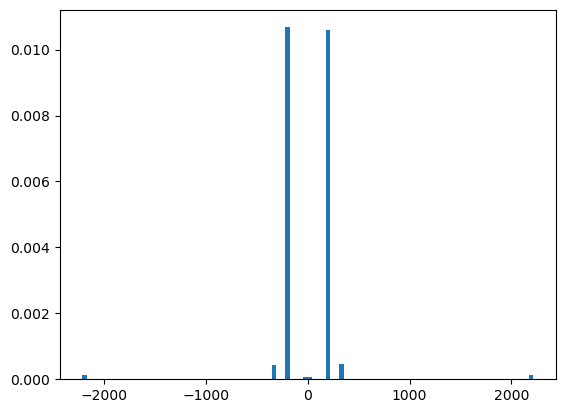

In [128]:
plt.hist(df[df['hemis_agreement']==False]['Rec_true_PDG'],bins=100)
plt.show()

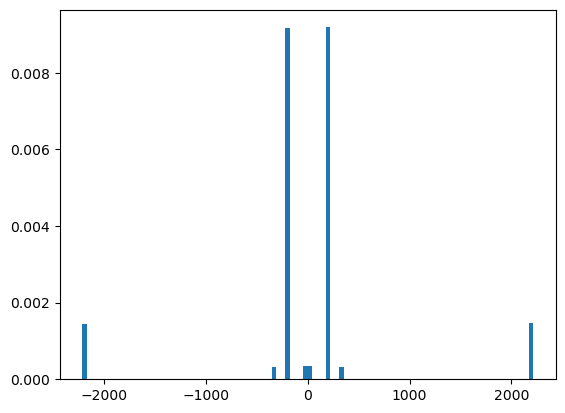

In [129]:
plt.hist(df[df['hemis_agreement']==True]['Rec_true_PDG'],bins=100,density=True)
plt.show()

## Looking at misallocation rate for signal MC

In [2]:
# file location Bs signal
filepath = "/r02/lhcb/rrm42/fcc/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/stage2/p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu/chunk_0.root"
# Create instance of uproot, we have opened the file
uproot_file = uproot.open( filepath)

# Look at trees in file
print( "Trees : " , uproot_file.keys() )

# We want output events
tree = uproot_file['events']

'''
print( "Variables:" )

for branch in tree.keys():
    print( branch )
'''

# Get data out

# define variables we want out

branches_rec_vtx = [
    "Rec_vtx_ntracks",
    "Rec_vtx_chi2",
    "Rec_vtx_isPV",
    "Rec_vtx_m",
    "Rec_vtx_x",
    "Rec_vtx_y",
    "Rec_vtx_z",
    "Rec_vtx_xerr",
    "Rec_vtx_yerr",
    "Rec_vtx_zerr",
    "Rec_vtx_d2PV_signed",
    "Rec_vtx_d2PV_x",
    "Rec_vtx_d2PV_y",
    "Rec_vtx_d2PV_z",
    "Rec_vtx_d2PV_err",
    "Rec_vtx_d2PV_xerr",
    "Rec_vtx_d2PV_yerr",
    "Rec_vtx_d2PV_zerr",
    "Rec_vtx_normd2PV_signed",
    "Rec_vtx_normd2PV_x",
    "Rec_vtx_normd2PV_y",
    "Rec_vtx_normd2PV_z",
    "Rec_vtx_thrustCosTheta",
    "Rec_vtx_in_hemisEmin"
]


branches_rec = [
    "Rec_true_PDG",
    "Rec_true_e",
    "Rec_true_m",
    "Rec_true_q",
    "Rec_true_p",
    "Rec_true_pt",
    "Rec_true_px",
    "Rec_true_py",
    "Rec_true_pz",
    "Rec_true_eta",
    "Rec_true_phi",
    "Rec_true_orivtx_x",
    "Rec_true_orivtx_y",
    "Rec_true_orivtx_z",
    "Rec_true_M1",
    "Rec_true_M2",
    "Rec_true_M1ofM1",
    "Rec_true_M2ofM1",
    "Rec_true_M1ofM2",
    "Rec_true_M2ofM2",
    "Rec_type",
    "Rec_indvtx",
    "Rec_customid",
    "Rec_e",
    "Rec_m",
    "Rec_q",
    "Rec_p",
    "Rec_pt",
    "Rec_px",
    "Rec_py",
    "Rec_pz",
    "Rec_eta",
    "Rec_phi",
    "Rec_thrustCosTheta",
    "Rec_in_hemisEmin",
    "Rec_track_d0",
    "Rec_track_z0",
    "Rec_track_normd0",
    "Rec_track_normz0"
]

branches_evt = [
    "EVT_MVA1",
    "EVT_MVA2",
    "EVT_MVAComb",
    "EVT_Thrust_mag",
    "EVT_Thrust_x",
    "EVT_Thrust_y",
    "EVT_Thrust_z",
    "EVT_Thrust_xerr",
    "EVT_Thrust_yerr",
    "EVT_Thrust_zerr",
    "EVT_Thrust_deltaE",
    "EVT_hemisEmin_Emiss",
    "EVT_hemisEmax_Emiss",
    "EVT_hemisEmin_e",
    "EVT_hemisEmin_eCharged",
    "EVT_hemisEmin_eNeutral",
    "EVT_hemisEmin_n",
    "EVT_hemisEmin_nCharged",
    "EVT_hemisEmin_nNeutral",
    "EVT_hemisEmin_nDV",
    "EVT_hemisEmax_e",
    "EVT_hemisEmax_eCharged",
    "EVT_hemisEmax_eNeutral",
    "EVT_hemisEmax_n",
    "EVT_hemisEmax_nCharged",
    "EVT_hemisEmax_nNeutral",
    "EVT_hemisEmax_nDV",
    "EVT_hemisEmin_nKaon",
    "EVT_hemisEmin_nPion",
    "EVT_hemisEmin_maxeKaon",
    "EVT_hemisEmin_maxePion",
    "EVT_hemisEmin_maxeKaon_fromtruePV",
    "EVT_hemisEmin_maxePion_fromtruePV",
    "EVT_hemisEmin_maxeKaon_ind",
    "EVT_hemisEmin_maxePion_ind",
    "EVT_hemisEmax_nLept",
    "EVT_hemisEmax_nKaon",
    "EVT_hemisEmax_nPion",
    "EVT_hemisEmax_maxeLept",
    "EVT_hemisEmax_maxeKaon",
    "EVT_hemisEmax_maxePion",
    "EVT_hemisEmax_maxeLept_fromtruePV",
    "EVT_hemisEmax_maxeKaon_fromtruePV",
    "EVT_hemisEmax_maxePion_fromtruePV",
    "EVT_hemisEmax_maxeLept_ind",
    "EVT_hemisEmax_maxeKaon_ind",
    "EVT_hemisEmax_maxePion_ind",
    "EVT_hemisEmin_containsTau23Pi",
    "Rec_PV_ntracks",
    "Rec_PV_x",
    "Rec_PV_y",
    "Rec_PV_z",
    "Rec_thrustCosTheta_min_hemisEmin",
    "Rec_thrustCosTheta_max_hemisEmin",
    "Rec_thrustCosTheta_ave_hemisEmin",
    "Rec_thrustCosTheta_min_hemisEmax",
    "Rec_thrustCosTheta_max_hemisEmax",
    "Rec_thrustCosTheta_ave_hemisEmax",
    "Rec_thrustCosTheta_min_hemisEmin_noBrem",
    "Rec_thrustCosTheta_max_hemisEmin_noBrem",
    "Rec_thrustCosTheta_ave_hemisEmin_noBrem",
    "Rec_thrustCosTheta_min_hemisEmax_noBrem",
    "Rec_thrustCosTheta_max_hemisEmax_noBrem",
    "Rec_thrustCosTheta_ave_hemisEmax_noBrem",
    "Rec_track_d0_min_hemisEmin",
    "Rec_track_d0_max_hemisEmin",
    "Rec_track_d0_ave_hemisEmin",
    "Rec_track_z0_min_hemisEmin",
    "Rec_track_z0_max_hemisEmin",
    "Rec_track_z0_ave_hemisEmin",
    "Rec_track_d0_min_hemisEmax",
    "Rec_track_d0_max_hemisEmax",
    "Rec_track_d0_ave_hemisEmax",
    "Rec_track_z0_min_hemisEmax",
    "Rec_track_z0_max_hemisEmax",
    "Rec_track_z0_ave_hemisEmax",
    "Rec_vtx_d2PV_min_hemisEmin",
    "Rec_vtx_d2PV_max_hemisEmin",
    "Rec_vtx_d2PV_ave_hemisEmin",
    "Rec_vtx_d2PV_min_hemisEmax",
    "Rec_vtx_d2PV_max_hemisEmax",
    "Rec_vtx_d2PV_ave_hemisEmax",
    "Rec_vtx_ntracks_min_hemisEmin",
    "Rec_vtx_ntracks_max_hemisEmin",
    "Rec_vtx_ntracks_ave_hemisEmin",
    "Rec_vtx_ntracks_min_hemisEmax",
    "Rec_vtx_ntracks_max_hemisEmax",
    "Rec_vtx_ntracks_ave_hemisEmax",
    "Rec_vtx_thrustCosTheta_min_hemisEmin",
    "Rec_vtx_thrustCosTheta_max_hemisEmin",
    "Rec_vtx_thrustCosTheta_ave_hemisEmin",
    "Rec_vtx_thrustCosTheta_min_hemisEmax",
    "Rec_vtx_thrustCosTheta_max_hemisEmax",
    "Rec_vtx_thrustCosTheta_ave_hemisEmax",
    "Rec_vtx_n",
    "Rec_track_n",
    "Rec_n"
]



branches_track = ["Rec_vtx_indRP",
]

branches_MC_evt_space = [
    "MCem_e",
    "MCem_m",
    "MCem_q",
    "MCem_p",
    "MCem_pt",
    "MCem_px",
    "MCem_py",
    "MCem_pz",
    "MCem_eta",
    "MCem_phi",
    "MCem_orivtx_x",
    "MCem_orivtx_y",
    "MCem_orivtx_z",
    "MCep_e",
    "MCep_m",
    "MCep_q",
    "MCep_p",
    "MCep_pt",
    "MCep_px",
    "MCep_py",
    "MCep_pz",
    "MCep_eta",
    "MCep_phi",
    "MCep_orivtx_x",
    "MCep_orivtx_y",
    "MCep_orivtx_z",
    "MCZ_e",
    "MCZ_m",
    "MCZ_q",
    "MCZ_p",
    "MCZ_pt",
    "MCZ_px",
    "MCZ_py",
    "MCZ_pz",
    "MCZ_eta",
    "MCZ_phi",
    "MCZ_orivtx_x",
    "MCZ_orivtx_y",
    "MCZ_orivtx_z",
    "MCq1_PDG",
    "MCq1_e",
    "MCq1_m",
    "MCq1_q",
    "MCq1_p",
    "MCq1_pt",
    "MCq1_px",
    "MCq1_py",
    "MCq1_pz",
    "MCq1_eta",
    "MCq1_phi",
    "MCq1_orivtx_x",
    "MCq1_orivtx_y",
    "MCq1_orivtx_z",
    "MCq2_PDG",
    "MCq2_e",
    "MCq2_m",
    "MCq2_q",
    "MCq2_p",
    "MCq2_pt",
    "MCq2_px",
    "MCq2_py",
    "MCq2_pz",
    "MCq2_eta",
    "MCq2_phi",
    "MCq2_orivtx_x",
    "MCq2_orivtx_y",
    "MCq2_orivtx_z"
]



akar_EVT = tree.arrays(
    expressions = branches_evt, 
    library = 'ak' ,
)
akar_RP = tree.arrays(
    expressions = branches_rec , 
    library = 'ak' ,
)
akar_vtx = tree.arrays(
    expressions = branches_rec_vtx , 
    library = 'ak' ,
)

akar_track = tree.arrays(
    expressions = branches_track, 
    library = 'ak' ,
)

akar_MC_evtsp = tree.arrays(
    expressions = branches_MC_evt_space,
    library = 'ak',
)

# close file
#uproot_file.close()


Trees :  ['events;1', 'eventsProcessed;1', 'eventsSelected;1']


In [6]:
df_vtx = ak.to_dataframe(akar_vtx,how=None)
df_RP = ak.to_dataframe(akar_RP, how=None)
df_track = ak.to_dataframe(akar_track,how=None)
df_EVT = ak.to_dataframe(akar_EVT,how=None)

In [7]:
vtx_hemis_flag = df_vtx[0]['Rec_vtx_in_hemisEmin']
RP_hemis_flag = df_RP[0]['Rec_in_hemisEmin']
RP_indvtx = df_RP[0]['Rec_indvtx']

In [136]:
k=0
l=0
for i in range((len(df_EVT[0]['EVT_MVA1']))):
    for j in range(len(RP_indvtx[i])):
        if RP_indvtx[i][j] !=-999 and RP_indvtx[i][j] !=0:
            if vtx_hemis_flag[i][vtx_hemis_flag[i].index==RP_indvtx[i][j]].item() == RP_hemis_flag[i][j]:
                k+=1
            l+=1

            

In [137]:
k/l

0.9868246773560165

In [8]:
agreement=[]
for i in range((len(df_EVT[0]['EVT_MVA1']))):
    for j in range(len(RP_indvtx[i])):
        if RP_indvtx[i][j] !=-999 and RP_indvtx[i][j] !=0:
            agreement.append(vtx_hemis_flag[i][vtx_hemis_flag[i].index==RP_indvtx[i][j]].item() == RP_hemis_flag[i][j])
        if RP_indvtx[i][j] ==-999: 
            agreement.append('Nan')
        if RP_indvtx[i][j] ==0: 
            agreement.append('PV')
df = df_RP[0].loc[:,['Rec_in_hemisEmin','Rec_indvtx','Rec_true_PDG']]


In [9]:
df['hemis_agreement'] = agreement

In [10]:
df

Rec_in_hemisEmin  Rec_indvtx  Rec_true_PDG hemis_agreement
entry subentry                                                            
0     0                        1           0        -211.0              PV
      1                        0        -999        -211.0             Nan
      2                        1           0         211.0              PV
      3                        1           0         211.0              PV
      4                        1           0        -211.0              PV
...                          ...         ...           ...             ...
88781 31                       0        -999          22.0             Nan
      32                       0        -999          22.0             Nan
      33                       0        -999          22.0             Nan
      34                       0        -999          22.0             Nan
      35                       1        -999         130.0             Nan

[3157495 rows x 4 columns]

In [11]:
df[df['hemis_agreement']==False]

,,Rec_in_hemisEmin,Rec_indvtx,Rec_true_PDG,hemis_agreement
entry,subentry,,,,
12,14,1,2,-211.0,False
33,4,1,1,211.0,False
42,29,0,1,-211.0,False
69,20,1,1,-211.0,False
70,2,1,1,-211.0,False
...,...,...,...,...,...
88700,29,1,3,211.0,False
88740,26,1,1,211.0,False
88762,12,1,1,-211.0,False


In [12]:
df[df['hemis_agreement']==True]

Rec_in_hemisEmin  Rec_indvtx  Rec_true_PDG hemis_agreement
entry subentry                                                            
0     10                       1           1         211.0            True
      12                       1           1        -211.0            True
      15                       0           3         211.0            True
      16                       0           3        -211.0            True
      17                       0           2        -211.0            True
...                          ...         ...           ...             ...
88781 8                        0           2         -11.0            True
      9                        0           1          13.0            True
      10                       0           2        -321.0            True
      11                       0           2         321.0            True
      12                       0           1         321.0            True

[515425 rows x 4 columns]

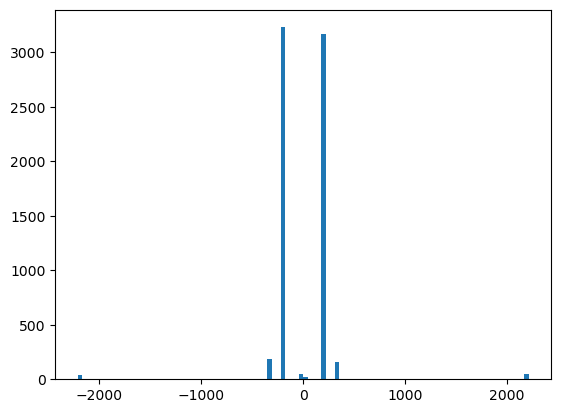

In [13]:
plt.hist(df[df['hemis_agreement']==False]['Rec_true_PDG'],bins=100)
plt.show()